# Subsampling Finale per ModernBERT

Partendo da `data/training/bert_training_dataset_aggregated.csv`:

1. Mostra la distribuzione dei campioni per categoria.
2. Unisce le classi **Research** e **Generic use** in un'unica label **Research & Generic use**.
3. Applica un subsampling bilanciato: per ogni classe seleziona casualmente fino a **4000** campioni (senza reinserimento; se < 4000, li prende tutti).
4. Salva il dataset risultante come `data/training/modernbert_final.csv`.

Nota: nessun oversampling / duplicazione — solo subsampling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

SEED = 42
MAX_PER_CLASS = 4000
np.random.seed(SEED)

## 1. Caricamento dataset

In [2]:
input_path = Path('../data/training/bert_training_dataset_aggregated.csv')
df = pd.read_csv(input_path)

print(f'Shape: {df.shape}')
print(f'Colonne: {list(df.columns)}')
df.head(3)

Shape: (34553, 2)
Colonne: ['description', 'Label']


,description,Label
0,strong demand for autonomous vehicles and the ...,"Automotive, Robotics, Industry"
1,driving simulators play a large role in develo...,"Automotive, Robotics, Industry"
2,a key functional block of visual navigation sy...,"Automotive, Robotics, Industry"


## 2. Distribuzione iniziale delle classi

Label
Automotive, Robotics, Industry    5950
Enterprise                        4793
Healthcare AI                     4752
Environment                       4566
Research                          4204
Generic use                       4193
Fintech and Marketing             3946
Media & Entertainment             2149
Name: count, dtype: int64

Totale classi: 8
Totale record: 34553


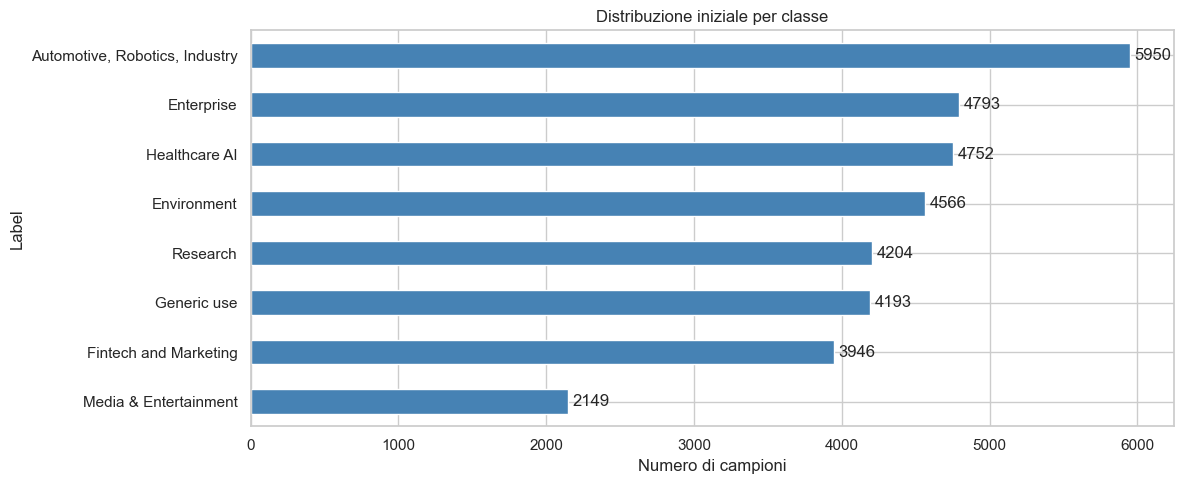

In [3]:
initial_counts = df['Label'].value_counts()
print(initial_counts)
print(f'\nTotale classi: {initial_counts.size}')
print(f'Totale record: {len(df)}')

ax = initial_counts.sort_values().plot(kind='barh', color='steelblue')
ax.set_title('Distribuzione iniziale per classe')
ax.set_xlabel('Numero di campioni')
for i, v in enumerate(initial_counts.sort_values().values):
    ax.text(v + 30, i, str(v), va='center')
plt.tight_layout()
plt.show()

## 3. Merge `Research` + `Generic use` → `Research & Generic use`

Label
Research & Generic use            8397
Automotive, Robotics, Industry    5950
Enterprise                        4793
Healthcare AI                     4752
Environment                       4566
Fintech and Marketing             3946
Media & Entertainment             2149
Name: count, dtype: int64

Totale classi dopo il merge: 7


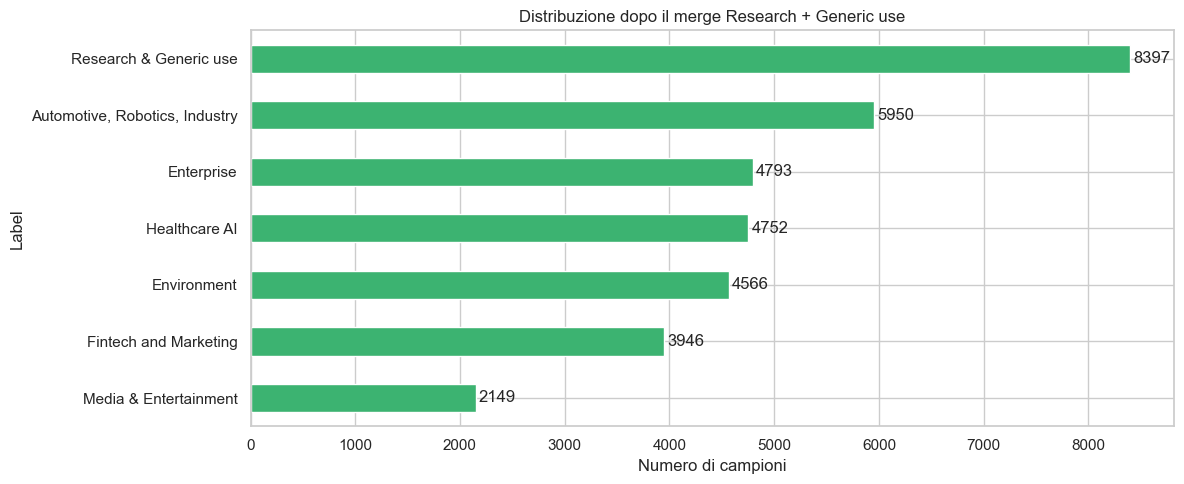

In [4]:
merge_map = {'Research': 'Research & Generic use', 'Generic use': 'Research & Generic use'}
df['Label'] = df['Label'].replace(merge_map)

merged_counts = df['Label'].value_counts()
print(merged_counts)
print(f'\nTotale classi dopo il merge: {merged_counts.size}')

ax = merged_counts.sort_values().plot(kind='barh', color='mediumseagreen')
ax.set_title('Distribuzione dopo il merge Research + Generic use')
ax.set_xlabel('Numero di campioni')
for i, v in enumerate(merged_counts.sort_values().values):
    ax.text(v + 30, i, str(v), va='center')
plt.tight_layout()
plt.show()

## 4. Subsampling bilanciato (max 4000 per classe, senza reinserimento)

In [5]:
parts = [
    g.sample(n=min(len(g), MAX_PER_CLASS), random_state=SEED, replace=False)
    for _, g in df.groupby('Label')
]
df_final = (
    pd.concat(parts, ignore_index=True)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

final_counts = df_final['Label'].value_counts()
print(final_counts)
print(f'\nShape finale: {df_final.shape}')
print(f'Duplicati nel dataset di input: {df.duplicated().sum()}')
print(f'Duplicati nel dataset finale:   {df_final.duplicated().sum()}')
assert (final_counts <= MAX_PER_CLASS).all(), 'Classe oltre il cap!'


Label
Enterprise                        4000
Research & Generic use            4000
Healthcare AI                     4000
Environment                       4000
Automotive, Robotics, Industry    4000
Fintech and Marketing             3946
Media & Entertainment             2149
Name: count, dtype: int64

Shape finale: (26095, 2)
Duplicati nel dataset di input: 3456
Duplicati nel dataset finale:   2610


## 5. Confronto prima / dopo

                                prima  dopo
Label                                      
Media & Entertainment            2149  2149
Fintech and Marketing            3946  3946
Environment                      4566  4000
Healthcare AI                    4752  4000
Enterprise                       4793  4000
Automotive, Robotics, Industry   5950  4000
Research & Generic use           8397  4000


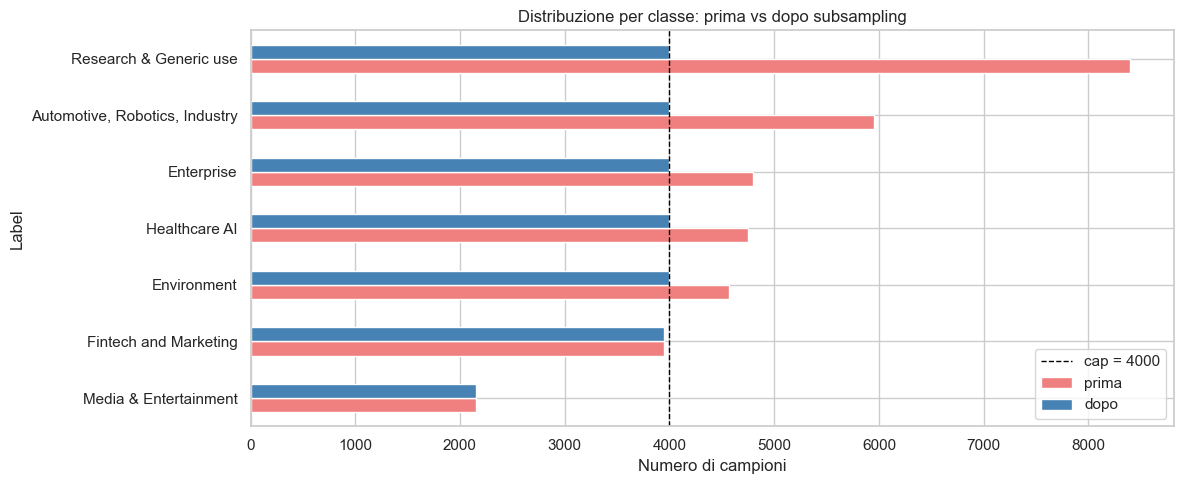

In [6]:
compare = (
    pd.DataFrame({'prima': merged_counts, 'dopo': final_counts})
      .fillna(0).astype(int)
      .sort_values('prima')
)
print(compare)

ax = compare.plot(kind='barh', color=['lightcoral', 'steelblue'])
ax.set_title('Distribuzione per classe: prima vs dopo subsampling')
ax.set_xlabel('Numero di campioni')
ax.axvline(MAX_PER_CLASS, color='black', linestyle='--', linewidth=1, label=f'cap = {MAX_PER_CLASS}')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Salvataggio

In [7]:
output_path = Path('../data/training/modernbert_final.csv')
df_final.to_csv(output_path, index=False)

print(f'Salvato: {output_path.resolve()}')
print(f'Shape: {df_final.shape}')
print(f'Classi: {df_final["Label"].nunique()}')

Salvato: /Users/gabrielevianello/Documents/Università/UnivPM/Paper/Organizzazione dell'Impresa/open-data-analytics/data/training/modernbert_final.csv
Shape: (26095, 2)
Classi: 7
